# K-Means Zone-Level Traffic Clustering

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [7]:

df = pd.read_csv("../data/Banglore_traffic_Dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Traffic Volume'] = pd.to_numeric(df['Traffic Volume'], errors='coerce')
df['Congestion Level'] = pd.to_numeric(df['Congestion Level'], errors='coerce')

df = df.dropna(subset=['Traffic Volume','Congestion Level'])
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [8]:

area_coords = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Koramangala": (12.9352, 77.6245),
    "Electronic City": (12.8452, 77.6600),
    "Hebbal": (13.0358, 77.5970),
    "MG Road": (12.9758, 77.6096),
    "Jayanagar": (12.9250, 77.5938),
    "Marathahalli": (12.9591, 77.6974)
}

df['lat'] = df['Area Name'].map(lambda x: area_coords.get(x,(np.nan,np.nan))[0])
df['lon'] = df['Area Name'].map(lambda x: area_coords.get(x,(np.nan,np.nan))[1])
df = df.dropna(subset=['lat','lon'])


In [9]:

X = df[['lat','lon','Traffic Volume','Congestion Level']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['zone_cluster'] = kmeans.fit_predict(X_scaled)

df['zone_cluster'].value_counts()


zone_cluster
2    2144
0    1394
1    1272
4     949
3     942
Name: count, dtype: int64

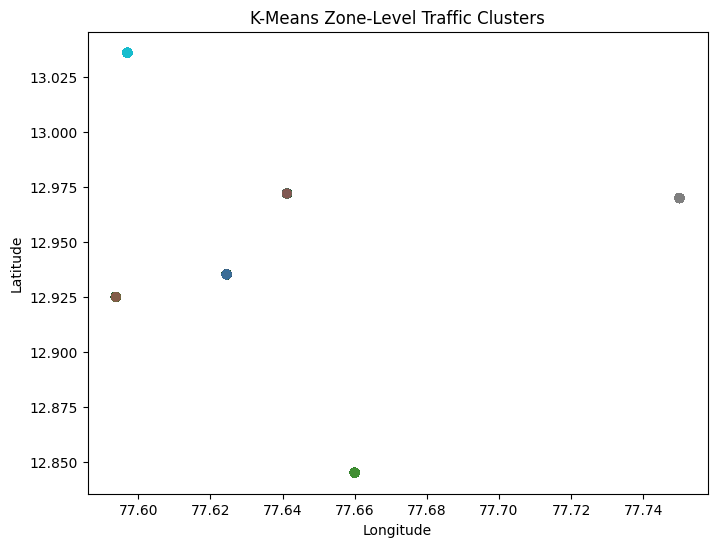

In [10]:

plt.figure(figsize=(8,6))
plt.scatter(df['lon'], df['lat'], c=df['zone_cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Zone-Level Traffic Clusters")
plt.show()


In [ ]:
zones = df[['Area Name', 'lat', 'lon', 'zone_cluster']]
zones.to_csv("../backend/data/zones.csv", index=False)


: 